In [1]:
# Import pandas for working with tabular data
import pandas as pd

# Load the original dataset
df = pd.read_csv("depression_data.csv")

# Confirm the dataset loaded and preview five records
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (413768, 16)


,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


In [2]:
# Count missing values in each column
missing_count = df.isna().sum()

# Calculate the percentage missing in each column
missing_percentage = (missing_count / len(df)) * 100

# Combine the results into a summary table
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage.round(2)
})

display(missing_summary)

# Count missing cells across the entire dataset
print("Total missing values:", missing_count.sum())

,Missing Count,Missing Percentage
Name,0,0.0
Age,0,0.0
Marital Status,0,0.0
Education Level,0,0.0
Number of Children,0,0.0
Smoking Status,0,0.0
Physical Activity Level,0,0.0
Employment Status,0,0.0
Income,0,0.0
Alcohol Consumption,0,0.0


Total missing values: 0


In [3]:
# Select text columns
text_columns = df.select_dtypes(include=["object", "string"]).columns

# Possible missing-value markers to investigate
placeholders = ["?", "unknown", "n/a", "na", "null", "none", "nan"]

results = []

for column in text_columns:
    # Standardize text temporarily for checking
    text = df[column].astype("string").str.strip().str.lower()

    results.append({
        "Column": column,
        "Blank Entries": text.eq("").sum(),
        "Possible Placeholders": text.isin(placeholders).sum()
    })

# Display the results
hidden_missing_summary = pd.DataFrame(results)
display(hidden_missing_summary)

,Column,Blank Entries,Possible Placeholders
0,Name,0,0
1,Marital Status,0,0
2,Education Level,0,0
3,Smoking Status,0,0
4,Physical Activity Level,0,0
5,Employment Status,0,0
6,Alcohol Consumption,0,0
7,Dietary Habits,0,0
8,Sleep Patterns,0,0
9,History of Mental Illness,0,0


## Missing-data findings and handling decision

- No missing values were detected using isna().
- No empty or whitespace-only text entries were found.
- No matches were found for the checked placeholder strings:
  ?, unknown, n/a, na, null, none, and nan.
- Therefore, no imputation or row removal was necessary based on
  these checks. The dataset was left unchanged.

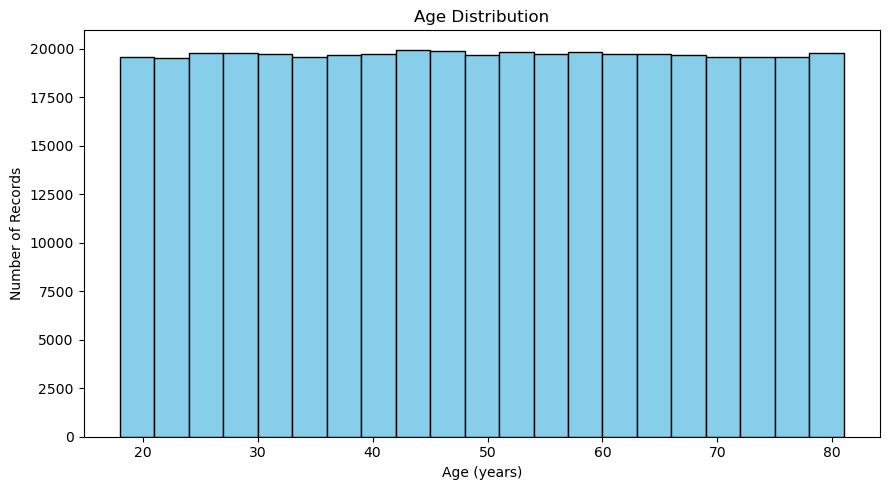

In [4]:
import matplotlib.pyplot as plt

# Equal-width bins, each covering three whole-number ages
age_bins = list(range(18, 82, 3))

plt.figure(figsize=(9, 5))
plt.hist(
    df["Age"],
    bins=age_bins,
    color="skyblue",
    edgecolor="black"
)

plt.title("Age Distribution")
plt.xlabel("Age (years)")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

## Age histogram interpretation

- Ages range from 18 to 80.
- Each bin covers a three-year interval.
- Bar heights are similar, indicating an approximately uniform age distribution.
- No single age interval strongly dominates the dataset.
- This describes the dataset; it does not prove that it represents
  the age distribution of the real population.